In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import permutation_importance

# Show all columns when printing
pd.set_option('display.max_columns', None)


In [116]:
target = pd.read_csv('src/data/training/processed/final_training_data.csv')
target['mix__sd_od_history_to_kyc_ratio'] = target['od__history_length_days'] / target['sd__age_since_first_kyc']
target = target.drop(columns=['user_id', 'reference_date'])

In [117]:
# Basic stats
print(target['t__ccf'].describe())

# Check for missing values
print(target['t__ccf'].isna().sum())

# Check skewness and kurtosis
print(f"Skewness: {target['t__ccf'].skew()}")
print(f"Kurtosis: {target['t__ccf'].kurt()}")


count    15534.000000
mean         0.966391
std          3.214270
min          0.000000
25%          0.000000
50%          0.966905
75%          1.044157
max        187.432670
Name: t__ccf, dtype: float64
0
Skewness: 23.39852283705875
Kurtosis: 952.2781531849727


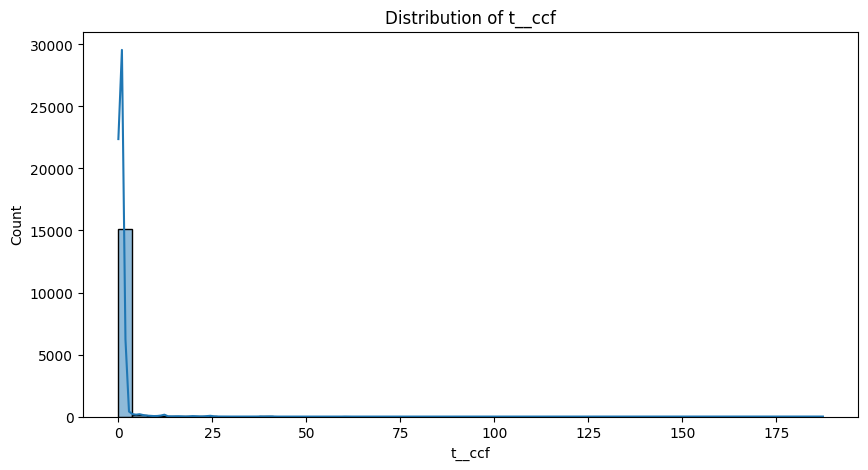

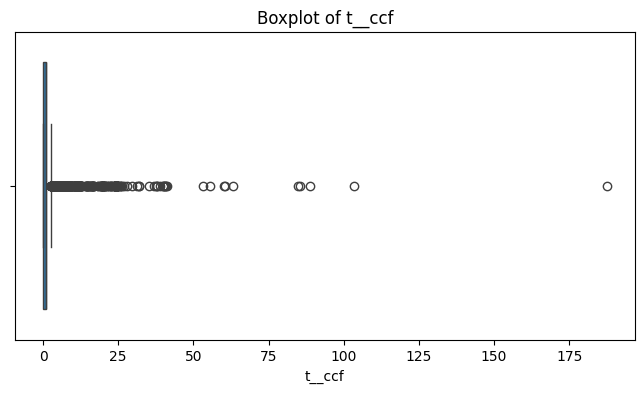

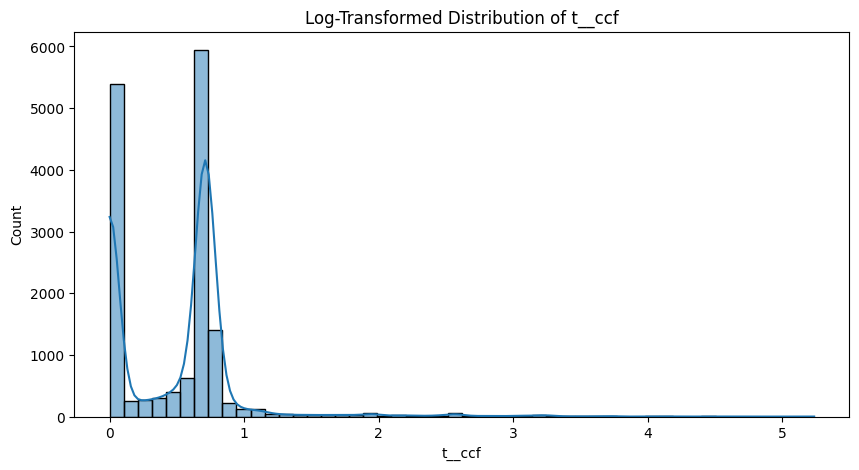

In [118]:
# Histogram + KDE
plt.figure(figsize=(10,5))
sns.histplot(target['t__ccf'], bins=50, kde=True)
plt.title('Distribution of t__ccf')
plt.show()

# Boxplot to detect outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=target['t__ccf'])
plt.title('Boxplot of t__ccf')
plt.show()

# Optionally, check for log-normality
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(target['t__ccf']), bins=50, kde=True)
plt.title('Log-Transformed Distribution of t__ccf')
plt.show()

In [119]:
target['t__ccf'] = target['t__ccf'].clip(upper=2)

In [120]:
# Basic stats
print(target['t__ccf'].describe())

# Check for missing values
print(target['t__ccf'].isna().sum())

# Check skewness and kurtosis
print(f"Skewness: {target['t__ccf'].skew()}")
print(f"Kurtosis: {target['t__ccf'].kurt()}")

count    15534.000000
mean         0.671419
std          0.563085
min          0.000000
25%          0.000000
50%          0.966905
75%          1.044157
max          2.000000
Name: t__ccf, dtype: float64
0
Skewness: 0.14924474504719784
Kurtosis: -0.8431407881708419


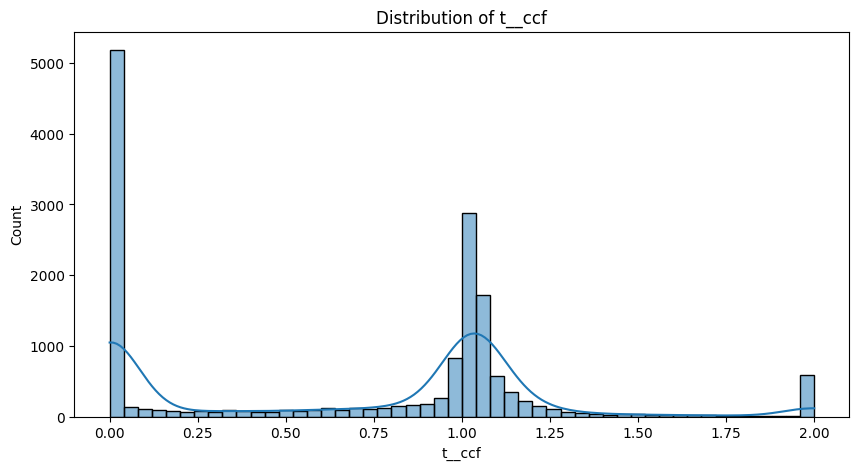

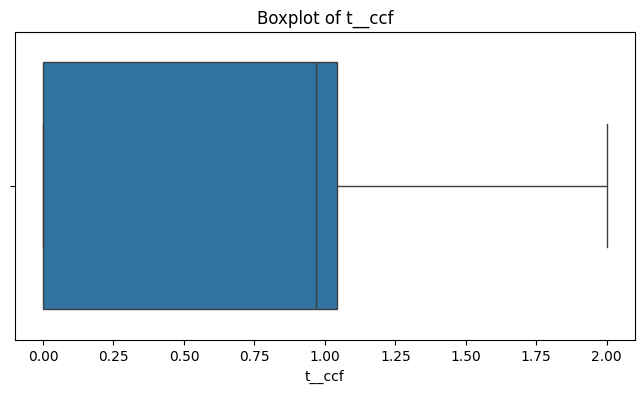

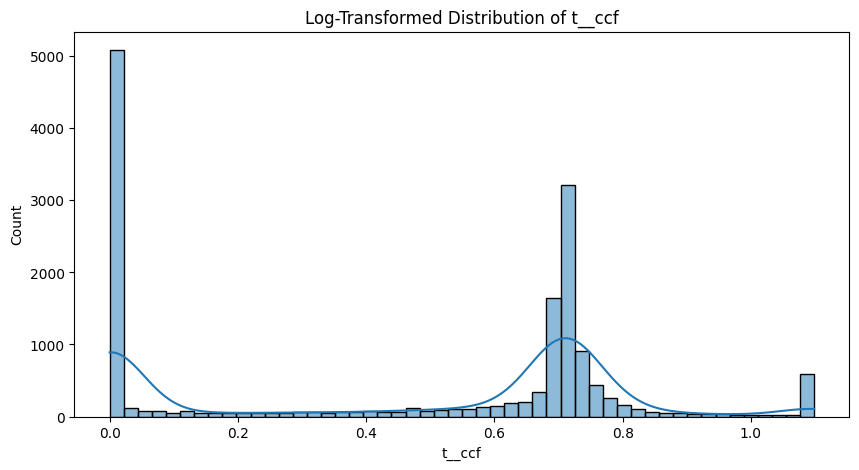

In [121]:
# Histogram + KDE
plt.figure(figsize=(10,5))
sns.histplot(target['t__ccf'], bins=50, kde=True)
plt.title('Distribution of t__ccf')
plt.show()

# Boxplot to detect outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=target['t__ccf'])
plt.title('Boxplot of t__ccf')
plt.show()

# Optionally, check for log-normality
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(target['t__ccf']), bins=50, kde=True)
plt.title('Log-Transformed Distribution of t__ccf')
plt.show()

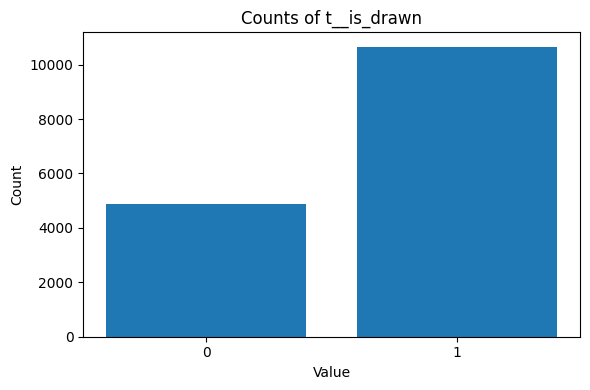

In [122]:
counts = target['t__is_drawn'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Counts of t__is_drawn")
plt.xlabel("Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [123]:
features = target.drop(columns=['t__ccf', 't__is_drawn'])
target_ccf = target['t__ccf']
target_is_drawn = target['t__is_drawn']

In [131]:
def plot_top_features(series, title):
    top = series.head(40).sort_values()
    plt.figure(figsize=(10,6))
    top.plot(kind='barh', color='skyblue')
    plt.title(title)
    plt.xlabel('Importance')
    plt.show()

In [132]:
# --- 1. Correlation ---
corr_ccf = features.corrwith(target_ccf).abs().sort_values(ascending=False)
corr_is_drawn = features.corrwith(target_is_drawn).abs().sort_values(ascending=False)

/Users/ilya.katliarou/Documents/CCF/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ilya.katliarou/Documents/CCF/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


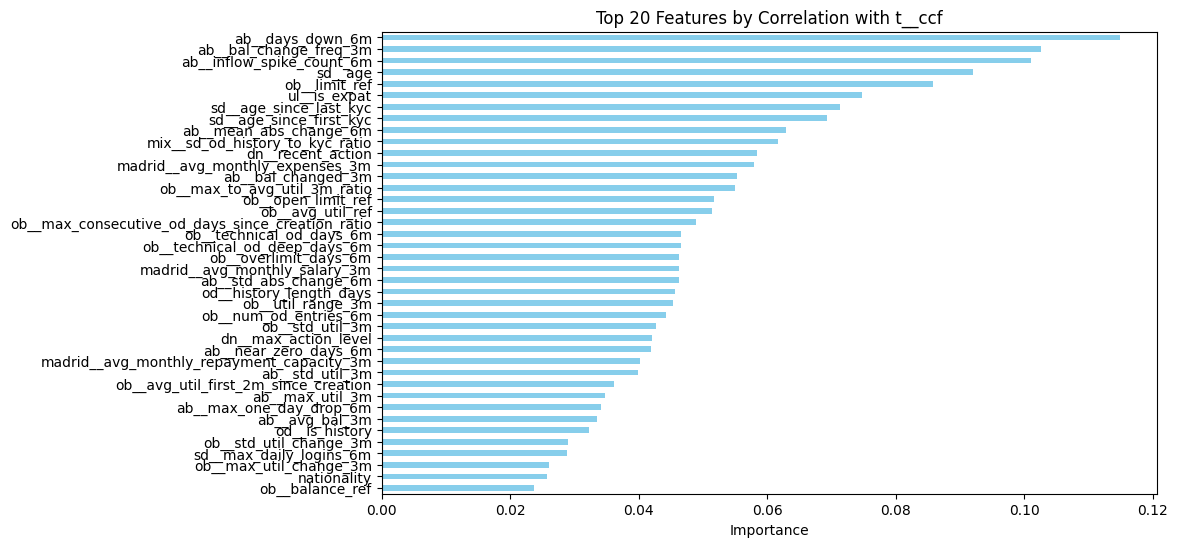

In [133]:
plot_top_features(corr_ccf, 'Top 20 Features by Correlation with t__ccf')

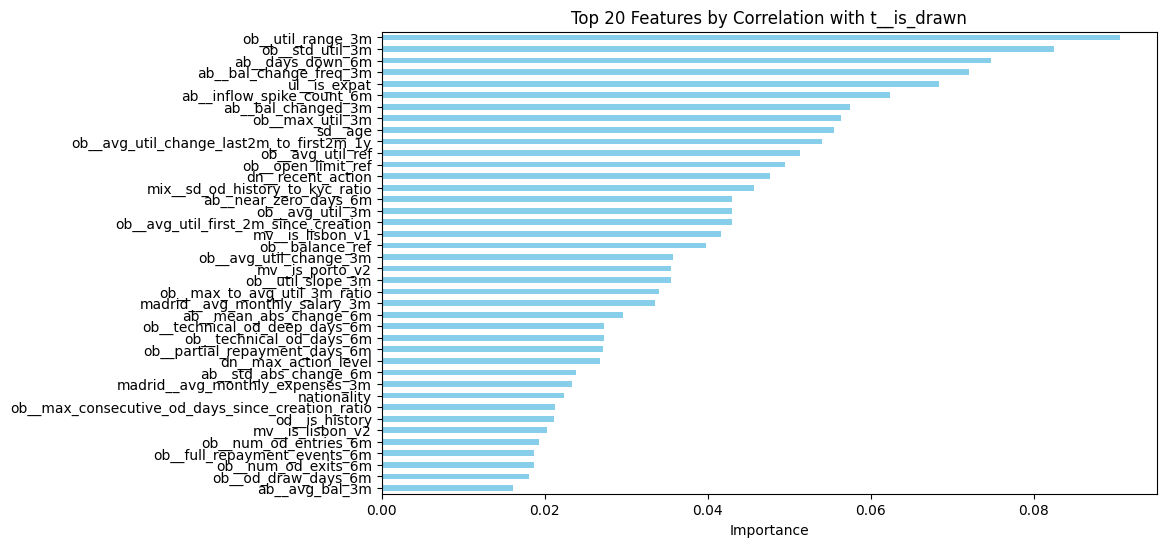

In [134]:
plot_top_features(corr_is_drawn, 'Top 20 Features by Correlation with t__is_drawn')

In [135]:
# --- 2. Mutual Information ---
mi_ccf = pd.Series(mutual_info_regression(features, target_ccf), index=features.columns).sort_values(ascending=False)
mi_is_drawn = pd.Series(mutual_info_classif(features, target_is_drawn), index=features.columns).sort_values(ascending=False)

ValueError: Input X contains NaN.

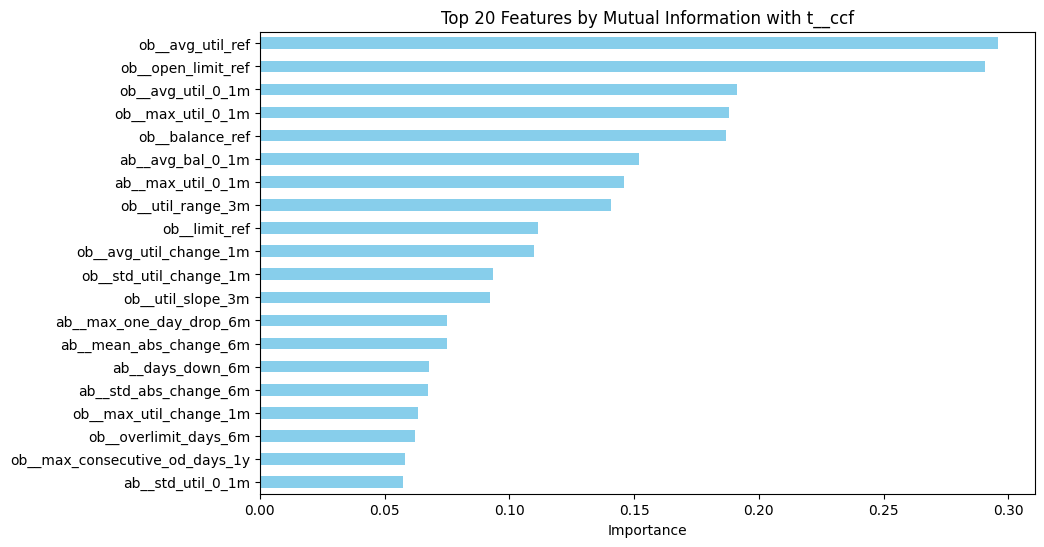

In [29]:
plot_top_features(mi_ccf, 'Top 20 Features by Mutual Information with t__ccf')

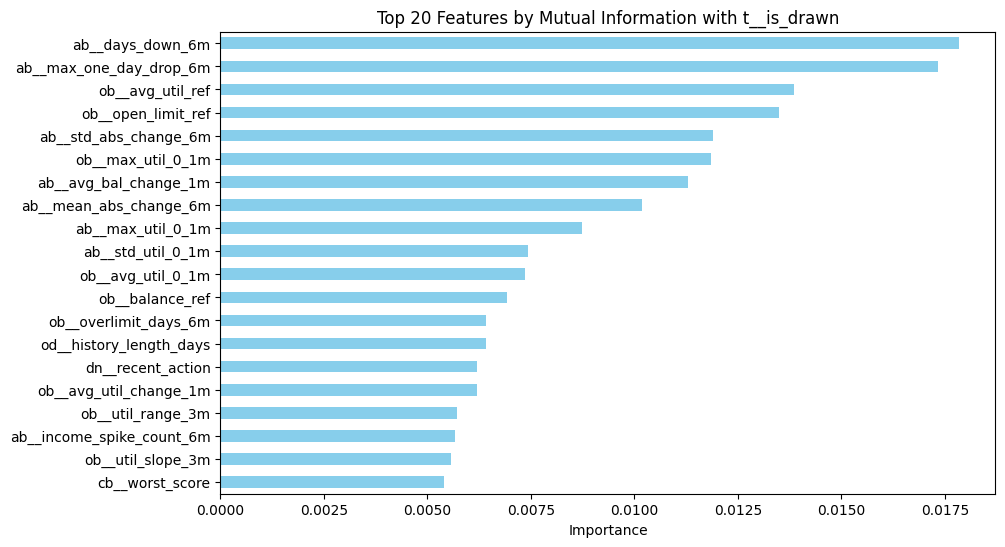

In [30]:
plot_top_features(mi_is_drawn, 'Top 20 Features by Mutual Information with t__is_drawn')

In [128]:
# --- 3. Random Forest Importance ---
rf_ccf = RandomForestRegressor(n_estimators=500, random_state=42)
rf_ccf.fit(features, target_ccf)
rf_ccf_imp = pd.Series(rf_ccf.feature_importances_, index=features.columns).sort_values(ascending=False)

rf_is_drawn = RandomForestClassifier(n_estimators=500, random_state=42)
rf_is_drawn.fit(features, target_is_drawn)
rf_is_drawn_imp = pd.Series(rf_is_drawn.feature_importances_, index=features.columns).sort_values(ascending=False)

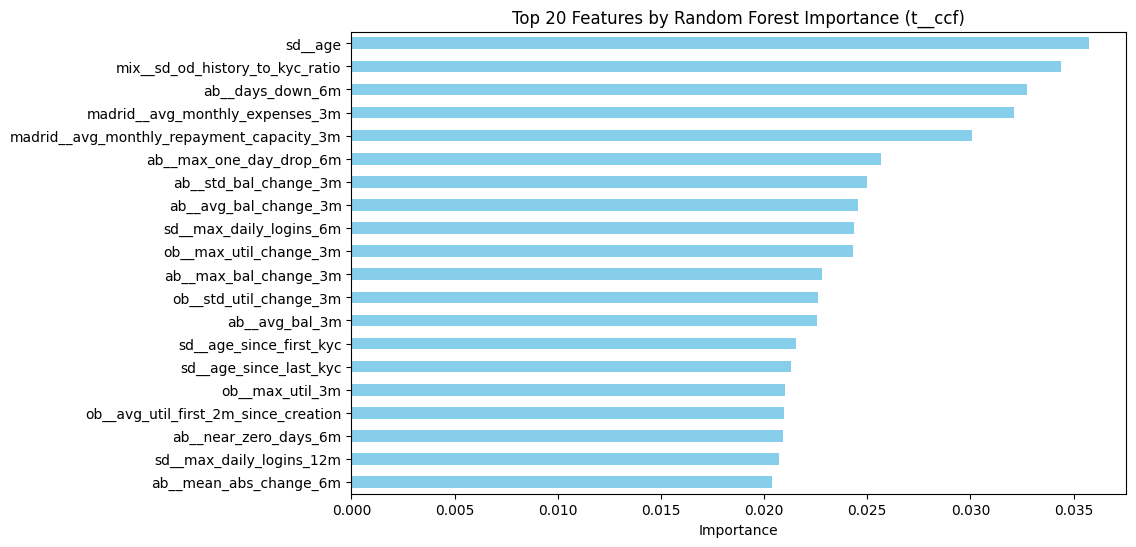

In [129]:
plot_top_features(rf_ccf_imp, 'Top 20 Features by Random Forest Importance (t__ccf)')

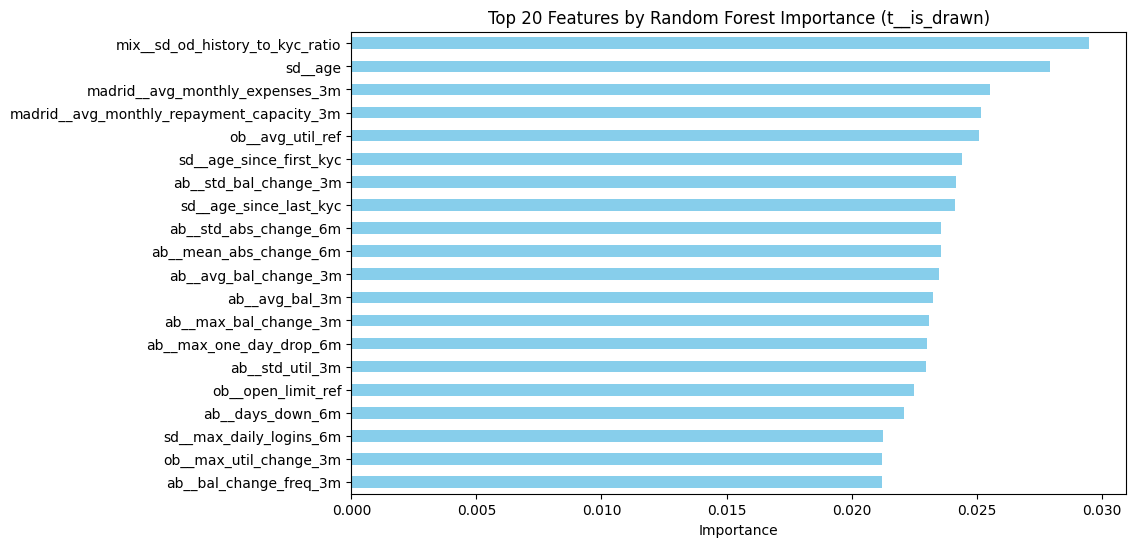

In [130]:
plot_top_features(rf_is_drawn_imp, 'Top 20 Features by Random Forest Importance (t__is_drawn)')

In [38]:
# --- 4. Permutation Importance ---
perm_ccf = permutation_importance(rf_ccf, features, target_ccf, n_repeats=10, random_state=42)
perm_ccf_imp = pd.Series(perm_ccf.importances_mean, index=features.columns).sort_values(ascending=False)

perm_is_drawn = permutation_importance(rf_is_drawn, features, target_is_drawn, n_repeats=10, random_state=42)
perm_is_drawn_imp = pd.Series(perm_is_drawn.importances_mean, index=features.columns).sort_values(ascending=False)

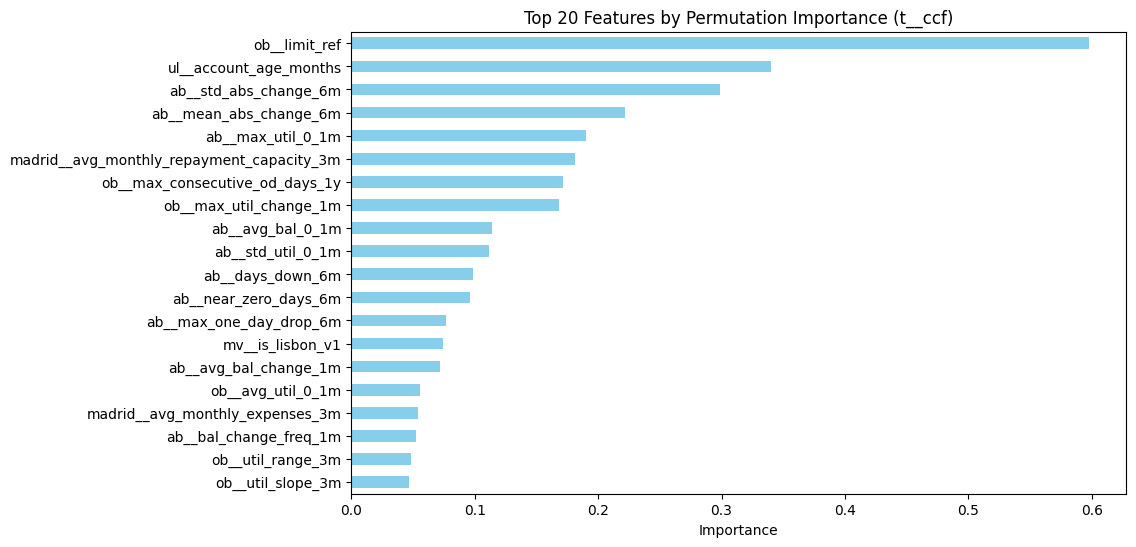

In [39]:
plot_top_features(perm_ccf_imp, 'Top 20 Features by Permutation Importance (t__ccf)')

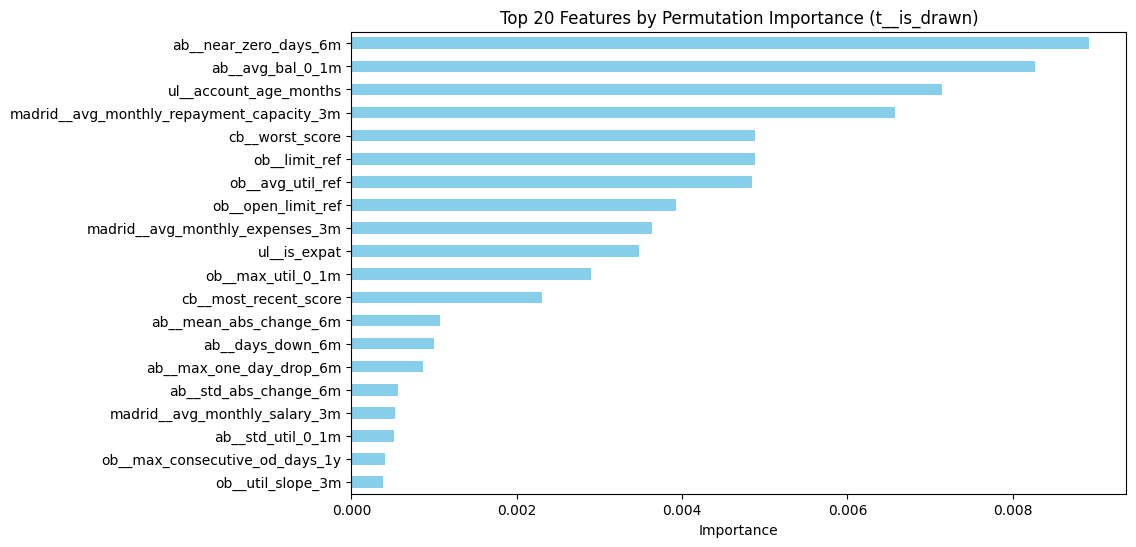

In [40]:
plot_top_features(perm_is_drawn_imp, 'Top 20 Features by Permutation Importance (t__is_drawn)')

In [65]:
from collections import Counter

# --- Function to get features in top 20 in at least n metrics ---
def top_features_in_at_least_n(top_lists, n=4):
    all_features = [feat for lst in top_lists for feat in lst]
    counts = Counter(all_features)
    return {feat for feat, c in counts.items() if c >= n}

# --- Prepare top 20 lists for t__ccf ---
top_corr_ccf = list(corr_ccf.head(20).index)
top_mi_ccf = list(mi_ccf.head(20).index)
top_rf_ccf = list(rf_ccf_imp.head(20).index)
top_perm_ccf = list(perm_ccf_imp.head(20).index)

# Features appearing in top 20 in at least 2 metrics
common_ccf_2plus = top_features_in_at_least_n([top_corr_ccf, top_mi_ccf, top_rf_ccf, top_perm_ccf], n=3)
print("t__ccf features in top 20 of at least 2 metrics:", common_ccf_2plus)

# --- Prepare top 20 lists for t__is_drawn ---
top_corr_is_drawn = list(corr_is_drawn.head(20).index)
top_mi_is_drawn = list(mi_is_drawn.head(20).index)
top_rf_is_drawn = list(rf_is_drawn_imp.head(20).index)
top_perm_is_drawn = list(perm_is_drawn_imp.head(20).index)

# Features appearing in top 20 in at least 2 metrics
common_is_drawn_2plus = top_features_in_at_least_n([top_corr_is_drawn, top_mi_is_drawn, top_rf_is_drawn, top_perm_is_drawn], n=3)
print("t__is_drawn features in top 20 of at least 2 metrics:", common_is_drawn_2plus)


t__ccf features in top 20 of at least 2 metrics: {'ob__avg_util_0_1m', 'ob__limit_ref', 'ob__util_slope_3m', 'ab__max_util_0_1m', 'ob__util_range_3m', 'ul__account_age_months', 'ab__days_down_6m', 'ab__max_one_day_drop_6m', 'ab__mean_abs_change_6m', 'ab__std_abs_change_6m', 'ab__std_util_0_1m', 'ab__avg_bal_0_1m', 'ob__std_util_change_1m', 'ob__max_consecutive_od_days_1y', 'ab__near_zero_days_6m', 'ob__max_util_change_1m'}
t__is_drawn features in top 20 of at least 2 metrics: {'ob__avg_util_ref', 'ob__open_limit_ref', 'ob__util_slope_3m', 'ob__max_util_0_1m', 'ab__days_down_6m', 'ab__max_one_day_drop_6m', 'ab__std_abs_change_6m', 'ab__mean_abs_change_6m', 'ab__std_util_0_1m', 'ab__near_zero_days_6m'}


In [ ]:
['ob__avg_util_0_1m', 'ob__limit_ref']

In [57]:
# --- Top 20 sets for t__ccf ---
top_corr_ccf = set(corr_ccf.head(20).index)
top_mi_ccf = set(mi_ccf.head(20).index)
top_rf_ccf = set(rf_ccf_imp.head(20).index)
top_perm_ccf = set(perm_ccf_imp.head(20).index)

# Intersection across all 4 methods
common_ccf = top_corr_ccf & top_mi_ccf & top_rf_ccf & top_perm_ccf
print("Features consistently important for t__ccf:", common_ccf)

Features consistently important for t__ccf: {'ob__limit_ref', 'ab__days_down_6m', 'ab__avg_bal_0_1m', 'ob__max_consecutive_od_days_1y', 'ob__max_util_change_1m'}


In [56]:
# --- Top 20 sets for t__is_drawn ---
top_corr_is_drawn = set(corr_is_drawn.head(20).index)
top_mi_is_drawn = set(mi_is_drawn.head(20).index)
top_rf_is_drawn = set(rf_is_drawn_imp.head(20).index)
top_perm_is_drawn = set(perm_is_drawn_imp.head(20).index)

# Intersection across all 4 methods
common_is_drawn = top_corr_is_drawn & top_mi_is_drawn & top_rf_is_drawn & top_perm_is_drawn
print("Features consistently important for t__is_drawn:", common_is_drawn)

Features consistently important for t__is_drawn: {'ob__avg_util_ref', 'ob__util_slope_3m', 'ob__open_limit_ref', 'ab__days_down_6m'}
